
# 1. Members feature engineering

## integrated_data 불러오기 및 기준일 설정

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지: 운영체제별 기본 한글 폰트 지정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

TODAY = pd.to_datetime('2017-02-28')
df_all = pd.read_csv("../../data/processed/integrated_data.csv")


In [2]:
import easydict

args = easydict.EasyDict()
args.seed = 42
args.target = df_all['is_churn']

### 클래스 비율 확인

In [3]:
# 클래스 비율
df_all['is_churn'].value_counts()
df_all['is_churn'].value_counts() / df_all.shape[0]

# 전체 평균 이탈률: 모든 그래프의 비교 기준선
OVERALL = df_all["is_churn"].mean()  
print(f"전체 이탈률: {OVERALL:.2%}")

전체 이탈률: 8.95%


### member 관련 feature 엔지니어링

#### 멤버정보가 없는 멤버 관련 피쳐 생성

In [4]:
member_cols = ['city', 'bd', 'registered_via', 'registration_init_time']
df_all['has_member'] = (~df_all[member_cols].isna().all(axis=1)).astype(int)
#msno는있지만 다른 정보가 없는사람과 있는사람을 구분하는 컬럼
df_all['has_member'].value_counts()

has_member
1    88648
0    11352
Name: count, dtype: int64

#### registration_init_time

In [5]:
df_all['registration_init_time']= df_all['registration_init_time'].astype('Int64')

In [6]:
df_all['registration_init_time'] = pd.to_datetime(
    df_all['registration_init_time'].astype(str),
    format='%Y%m%d',     # 연4·월2·일2
    errors='coerce',     # 변환 불가 값은 에러 대신 NaN
)

reg = df_all['registration_init_time']
df_all['tenure_date'] = (TODAY- reg).dt.days  #가입 후 경과 일수


In [7]:

df_all['reg_year'] = reg.dt.year                            # 가입 연도




season_map = {3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름',
              9: '가을', 10: '가을', 11: '가을', 12: '겨울', 1: '겨울', 2: '겨울'}
df_all['reg_season'] = reg.dt.month.map(season_map)         # 결측은 NaN → 10단계에서 채움

# 같은 날 가입 인원. groupby는 결측 키를 기본으로 빼서, members 없는 사람은 NaN
df_all['same_join_day'] = df_all.groupby('registration_init_time')['msno'].transform('count')

#### gender

In [8]:
# 성별: 결측을 '미입력'이라는 하나의 그룹으로 취급
df_all["gender_status"] = df_all["gender"].fillna("미입력")
df_all["gender_status"].unique()

array(['female', '미입력', 'male'], dtype=object)

#### bd

In [9]:
# ── 4. 나이 정제 ──
bd = df_all['bd'].astype(float)
df_all['bd_clean'] = bd.where(bd.between(10, 80))           # 10~80세만 남기고 나머지 NaN
df_all['bd_isnan'] = df_all['bd_clean'].isna().astype(int)  # 나이 모름 = 1

# ── 5. 가입 당시 나이 ──
df_all['age_at_reg'] = df_all['bd_clean'] - df_all['tenure_date'] / 365

In [10]:
df_all["bd_bin"] = pd.cut( # 피쳐로 사용은 나중에
    df_all['bd_clean'],
    bins=[10, 20, 30, 40, 50, 60, np.inf],  # 60세 이상 전체를 포함하도록 np.inf 활용
    labels=["10대", "20대", "30대", "40대", "50대", "60대 이상"],
    right=False,  # 이상 ~ 미만 설정
)

#### city

In [11]:
# ── 6. 도시 ──
df_all['city_miss'] = (df_all['city'] == 1).astype(int)    # city 1(기본값 추정) = 1. NaN은 False → 0

city_int = df_all['city'].fillna(-1).astype(int)            # 결측 → -1 (members 없음)
city_counts = city_int.value_counts()
rare_cities = city_counts[city_counts < 500].index.difference([-1])   # 500명 미만 도시 (-1은 제외)
df_all['city_clean'] = city_int.where(~city_int.isin(rare_cities), 777)  # 희소 도시 → 777(기타)

# ── 7. 가입 경로 결측 ──
df_all['registered_via'] = df_all['registered_via'].fillna(-1).astype(int)   # 결측 → -1

# ── 9. 계절 결측 ──
df_all['reg_season'] = df_all['reg_season'].fillna('unknown')

# ── 10. 범주형 지정 ──
cat_cols = ['registered_via', 'city_clean', 'gender_status', 'reg_season']
df_all[cat_cols] = df_all[cat_cols].astype('category')

In [12]:
# 1. city 값별 사용자 수 및 비중 확인
city_summary = df_all.groupby('city').agg(
    cnt=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

city_summary['ratio'] = (city_summary['cnt'] / len(df_all) * 100).round(2)
print(city_summary.sort_values(by='cnt', ascending=False).head(10))

# 2. city가 1 인 유저들이 성별(gender)이나 나이(bd)도 미입력(NaN/0)인 경우가 많은지 교차 확인
print(df_all[df_all['city'] == 1]['gender_status'].value_counts(normalize=True))
print(df_all[df_all['city'] == 1]['bd_isnan'].value_counts(normalize=True)) 
# city가 1인데 성별 미입력 96퍼, 나이 미입력 97퍼

    city    cnt  churn_rate  ratio
0    1.0  45747    0.063982  45.75
11  13.0   9914    0.122655   9.91
3    5.0   7281    0.130889   7.28
2    4.0   4756    0.137931   4.76
13  15.0   4524    0.125553   4.52
20  22.0   4252    0.120179   4.25
4    6.0   2621    0.141167   2.62
12  14.0   2028    0.114892   2.03
10  12.0   1159    0.121657   1.16
7    9.0    992    0.122984   0.99
gender_status
미입력       0.968370
female    0.016416
male      0.015214
Name: proportion, dtype: float64
bd_isnan
1    0.974031
0    0.025969
Name: proportion, dtype: float64


#### member데이터아닌 다른 데이터 피쳐 엔지니어링

In [13]:
# ── 1. 가입 기간으로 나누기 ──
# 30일 미만은 30일로 올려서 나누기 폭주 방지. 가입정보 없으면 NaN

TRANS_START = pd.to_datetime('2015-01-01')
active_days = (TODAY - df_all['registration_init_time'].clip(lower=TRANS_START)).dt.days
active_years = active_days.clip(lower=30) / 365



df_all['trans_per_year']  = df_all['transaction_count'] / active_years   # 1년에 결제한 횟수
df_all['pay_per_year']    = df_all['total_payment'] / active_years       # 1년에 낸 금액
df_all['cancel_per_year'] = df_all['cancel_count'] / active_years        # 1년에 해지한 횟수


# ── 3. 데이터 유무 3부류 ──
df_all['data_group'] = np.select(
    [df_all['has_member'] == 0, df_all['has_log'] == 0],
    ['정보·로그 없음', '로그만 없음'],
    default='둘 다 있음',
)
df_all['data_group'] = df_all['data_group'].astype('category')

In [14]:
# 교차에 쓸 그룹 컬럼 (그래프용, 모델에는 안 넣음)
df_all['tenure_grp'] = pd.cut(df_all['tenure_date'],
                               bins=[-1, 365, 730, 1825, np.inf],
                               labels=['1년 미만', '1~2년', '2~5년', '5년 이상'])
df_all['age_grp'] = pd.cut(df_all['bd_clean'], bins=[9, 19, 29, 39, 80],
                            labels=['10대', '20대', '30대', '40대+'])

def age_log_diff(df, col):
    has_log = df['has_log'] == 1
    med = df[has_log].groupby('age_grp', observed=True)[col].median()   # 연령대별 중앙값
    diff = df[col] - df['age_grp'].map(med).astype(float)             # 내 값 - 내 연령대 중앙값
    return diff.where(has_log)                                         # 로그 없는 사람은 NaN

df_all['age_activity_diff'] = age_log_diff(df_all, 'activity_days')
df_all['age_secs_diff']     = age_log_diff(df_all, 'total_secs')


In [15]:
df_all.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'bd_bin', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'tenure_grp',
       'age_grp', 'age_activity_diff', 'age_secs_diff'],
      dtype='object')

In [16]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    'reg_season',
]

numbers = [
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',
    
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',
    
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',
    
    'trans_per_year', 'pay_per_year',
]

all_col = categories + numbers

# 멋쟁이 팀원들의 피쳐 합치기

In [17]:

# H1. 최근 7일간 미이용 고객
df_all["inactive_7days"] = (
df_all["days_since_last_log"].gt(7) |
df_all["has_log"].eq(0)
).astype(int)

# H2. 청취시간 1시간당 완청 곡 수
listening_hours = df_all["total_secs"].replace(0, np.nan) / 3600

df_all["completed_per_hour"] = (
df_all["total_num_100"] / listening_hours
)

# H3. 과거 거래 취소 비율
tx_count = df_all["transaction_count"].replace(0, np.nan)

df_all["cancel_rate"] = (
df_all["cancel_count"] / tx_count
)

# H4. 자동 갱신 미사용 + 낮은 활동량
df_all["no_auto_renew_low_activity"] = (
    df_all["last_auto_renew"].eq(0) &
    df_all["activity_days"].le(5)
).astype(int)

# H5. 장기 가입 + 낮은 활동량
df_all["long_tenure_low_activity"] = (
    df_all["tenure_date"].ge(365) &
    df_all["activity_days"].le(5)
).astype(int)

In [18]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


def add_features(data):
    data = data.copy()

    # 0 값 자체가 의미를 가질 수 있는 보조 flag
    data["no_unique_song"] = (data["total_num_unq"] == 0).astype(int)
    data["zero_plan_days"] = (data["last_plan_days"] == 0).astype(int)

    data["avg_payment"] = safe_divide(
        data["total_payment"],
        data["transaction_count"]
    )

    # 이용 로그 관련
    data["avg_daily_secs"] = safe_divide(
        data["total_secs"],
        data["activity_days"]
    )

    data["avg_daily_complete"] = safe_divide(
        data["total_num_100"],
        data["activity_days"]
    )

    data["avg_daily_unq"] = safe_divide(
        data["total_num_unq"],
        data["activity_days"]
    )

    data["complete_per_unq"] = safe_divide(
        data["total_num_100"],
        data["total_num_unq"]
    )

    # 결제 효율 관련
    data["payment_per_plan_day"] = safe_divide(
        data["avg_payment"],
        data["last_plan_days"]
    )

    return data


df_all = add_features(df_all)


In [19]:
df_all.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'bd_bin', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'tenure_grp',
       'age_grp', 'age_activity_diff', 'age_secs_diff', 'inactive_7days',
       'completed_per_hour', 'cancel_rate', 'no_auto_renew_low_activity',
       'long_tenure_low_activity', 'no_unique_song', 'zero_plan_days',
       'avg_payment', 'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
       'complete_per_unq', 'payment_pe

In [20]:
base_members = ['registered_via', 'city_clean', 'gender_status']
team_base = ['transaction_count', 'cancel_count', 'total_payment',
             'last_auto_renew', 'last_is_cancel', 'last_plan_days',
             'cancel_on_last_date', 'has_transaction',          # days_to_expire 제외
             'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
             'days_since_last_log', 'has_log']

mine  = ['reg_season', 'has_member', 'tenure_date', 'same_join_day', 'bd_clean',
         'bd_isnan', 'age_at_reg', 'city_miss', 'trans_per_year', 'pay_per_year']
sohee = ['inactive_7days', 'completed_per_hour', 'cancel_rate',
         'no_auto_renew_low_activity', 'long_tenure_low_activity']
sunah = ['avg_payment', 'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
         'complete_per_unq', 'payment_per_plan_day', 'no_unique_song', 'zero_plan_days']

feature_sets = {
    '① 기본':        base_members + team_base,
    '② 기본 + 본인': base_members + team_base + mine,
    '③ 기본 + 소희': base_members + team_base + sohee,
    '④ 기본 + 선아': base_members + team_base + sunah,
    '⑤ 전체':        base_members + team_base + mine + sohee + sunah,
}

In [21]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    #'reg_season',
]

numbers = [
    # members (본인)
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',

    # 거래 (팀 통합)
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',

    # 로그 (팀 통합)
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',

    #members 결합 (본인)
    'trans_per_year', #'pay_per_year',

     # 소희
     #'inactive_7days', 'completed_per_hour', 'cancel_rate',
     #'no_auto_renew_low_activity', 'long_tenure_low_activity',

    # # 선아
    'avg_payment', 
    'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
    'complete_per_unq', 'payment_per_plan_day',
    'no_unique_song', 'zero_plan_days',
]

all_col = categories + numbers   # 4 + 36 = 40개

In [22]:
from sklearn.model_selection import train_test_split

df_all[categories] = df_all[categories].astype('category')

all_col = categories+numbers

feature = df_all[all_col]
target = df_all[targets]

x_train, x_test, y_train, y_test = train_test_split(feature, target, random_state=args.seed,test_size=0.2, stratify=args.target)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((80000, 33), (80000,), (20000, 33), (20000,))

In [23]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

from common.models import ModelType
from common.evaluate import get_score, evaluate

In [24]:
sys.path.append(str(Path('..').resolve()))

from common.evaluate import evaluate
from common.cross_validation import cv_compare
from common.parameter_tuning import CatObjective, LgbObjective, XgbObjective, run_study

c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
cv_default = cv_compare(["cat", "lgb", "xgb"], x_train[all_col], y_train, args.seed, categories)
display(cv_default.round(4))

cat 교차 검증 평균 점수: 0.8699 (±0.0047)
lgb 교차 검증 평균 점수: 0.8692 (±0.0035)
xgb 교차 검증 평균 점수: 0.8571 (±0.0049)


,cat,lgb,xgb
0,0.8674,0.8687,0.8513
1,0.8709,0.8711,0.8615
2,0.8699,0.8675,0.8551
3,0.8637,0.8642,0.8536
4,0.8778,0.8745,0.8642


In [27]:
study_cat = run_study(
    CatObjective(x_train[all_col], y_train, args.seed, categories,
                 iterations=(100, 200), lr=(0.03, 0.15),
                 depth=(4, 7), l2=(1, 10)),
    args.seed, n_trials=20,timeout=600)

Best Score: 0.8704170865141603
Best hp {'iterations': 100, 'learning_rate': 0.1438662644704, 'depth': 7, 'l2_leaf_reg': 8.275576133048151}


In [32]:
study_lgb = run_study(
    LgbObjective(x_train[all_col], y_train, args.seed,
                 n_estimators=(100, 200), lr=(0.03, 0.15),
                 num_leaves=(15, 63), min_child=(20, 100)),
    args.seed, n_trials=20,timeout=600)

Best Score: 0.8722133286018255
Best hp {'n_estimators': 100, 'learning_rate': 0.030203276771213837, 'num_leaves': 31, 'min_child_samples': 76}


In [ ]:
# study_xgb = run_study(
#     XgbObjective(x_train[all_col], y_train, args.seed,
#                  n_estimators=(300, 1000), lr=(0.01, 0.1),
#                  max_depth=(4, 8), min_child=(1, 10)),
#     args.seed, n_trials=20)

In [29]:
studies = {"cat": study_cat 
           ,"lgb": study_lgb 
           #,"xgb": study_xgb
           }

compare = pd.DataFrame({
    name: {"기본 설정": cv_default[name].mean(),
           "튜닝 후": studies[name].best_value}
    for name in studies
}).T
compare["향상"] = compare["튜닝 후"] - compare["기본 설정"]
display(compare.round(4))

,기본 설정,튜닝 후,향상
cat,0.8699,0.8704,0.0005
lgb,0.8692,0.8722,0.0030


In [30]:
best_name = compare["튜닝 후"].idxmax()
best_params = studies[best_name].best_params
print("선택된 모델:", best_name, "/ 적용 파라미터:", best_params)

final_model = ModelType[best_name].create(args.seed, **best_params)
fit_params = {"cat_features": categories} if best_name == "cat" else {}
final_model.fit(x_train[all_col], y_train, **fit_params)

score = evaluate(final_model, [x_train[all_col], y_train], [x_test[all_col], y_test])
display(pd.DataFrame({
    k: {"ROC-AUC": s["auc_score"], "PR-AUC": s["pr_auc"]} for k, s in score.items()
}).T.round(4))

선택된 모델: lgb / 적용 파라미터: {'n_estimators': 100, 'learning_rate': 0.030203276771213837, 'num_leaves': 31, 'min_child_samples': 76}


,ROC-AUC,PR-AUC
train_score,0.8893,0.6341
test_score,0.8717,0.6065


In [33]:
import optuna
optuna.visualization.plot_param_importances(studies[best_name]).show()
optuna.visualization.plot_optimization_history(studies[best_name]).show()

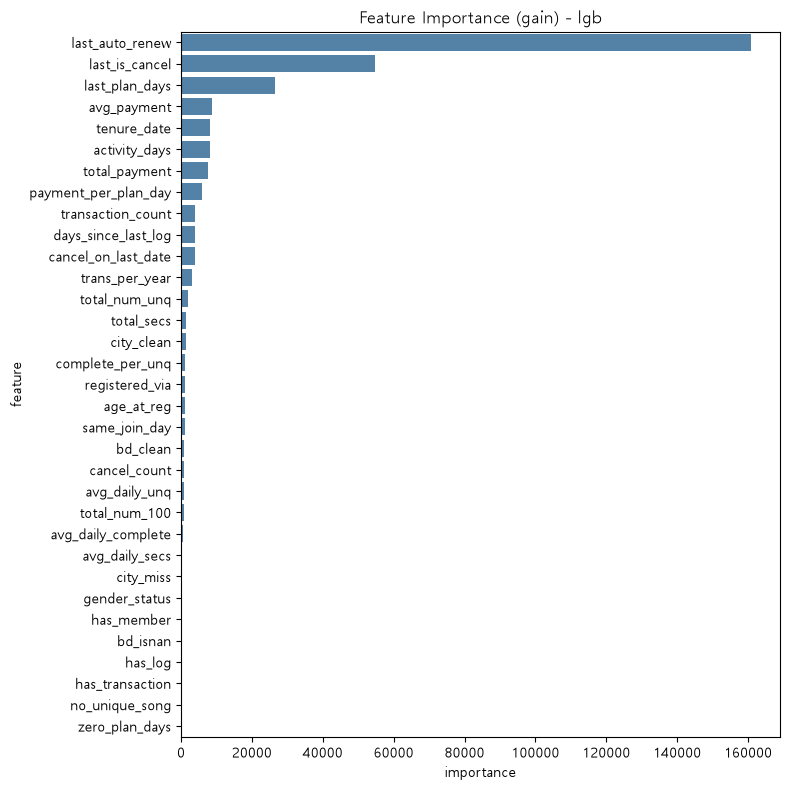

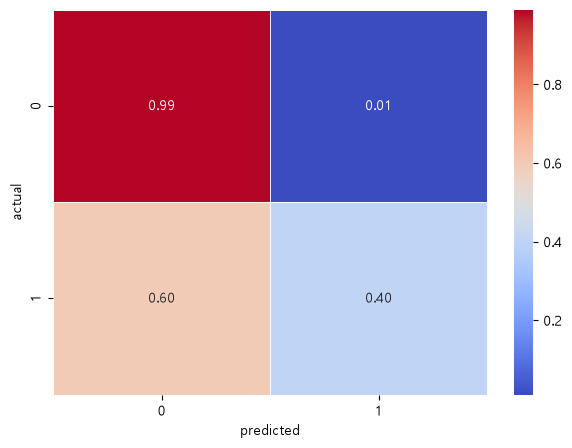

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     18210
           1       0.79      0.40      0.53      1790

    accuracy                           0.94     20000
   macro avg       0.87      0.70      0.75     20000
weighted avg       0.93      0.94      0.93     20000



In [34]:
# 피처 중요도 (최종 모델)
imp = pd.Series(
    final_model.feature_importances_,
    index=x_train[all_col].columns,
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=imp.values, y=imp.index, color='steelblue')
plt.title(f'Feature Importance (gain) - {best_name}')
plt.xlabel('importance')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

# 혼동행렬 (테스트, 0.5 기준)
conf_mx = score['test_score']['conf_mx']

plt.figure(figsize=(7, 5))
sns.heatmap(conf_mx, annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

print(score['test_score']['report'])

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=args.seed)
cv_model = ModelType[best_name].create(args.seed, **best_params)

proba_cv = cross_val_predict(cv_model, x_train[all_col], y_train, cv=skf,
                             method="predict_proba")[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, proba_cv)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best = f1[:-1].argmax()
TH = thresholds[best]
print(f"기준선: {TH:.3f} (재현율 {recall[best]:.3f}, 정밀도 {precision[best]:.3f})")

기준선: 0.280 (재현율 0.529, 정밀도 0.637)


              precision    recall  f1-score   support

           0       0.95      0.97      0.96     18210
           1       0.64      0.53      0.58      1790

    accuracy                           0.93     20000
   macro avg       0.79      0.75      0.77     20000
weighted avg       0.93      0.93      0.93     20000



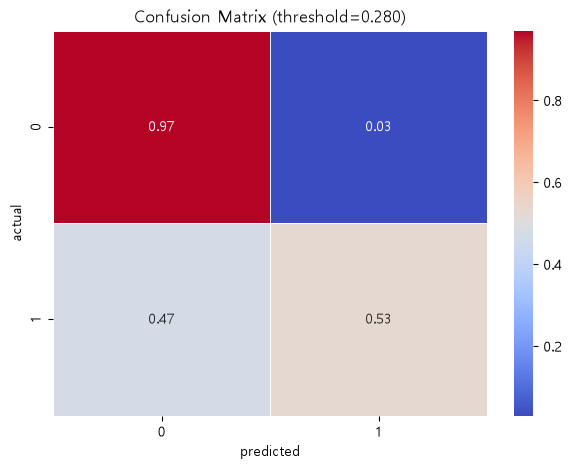

In [36]:
test_th = get_score(final_model, x_test[all_col], y_test, threshold=TH)
print(test_th['report'])

plt.figure(figsize=(7, 5))
sns.heatmap(test_th['conf_mx'], annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title(f'Confusion Matrix (threshold={TH:.3f})')
plt.show()

In [39]:
import shap

X_te = x_test[all_col]

# 학습된 모델을 넣는다
explainer = shap.TreeExplainer(final_model)
# 학습된 모델을 갖고 X_te를 예측
shap_values = explainer.shap_values(X_te)

shap_values.shape, X_te.shape

c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


((20000, 33), (20000, 33))

In [40]:
X_plot = X_te.copy()
for c in categories:
    X_plot[c] = X_plot[c].cat.codes

In [41]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0, :], X_plot.iloc[0, :])

c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


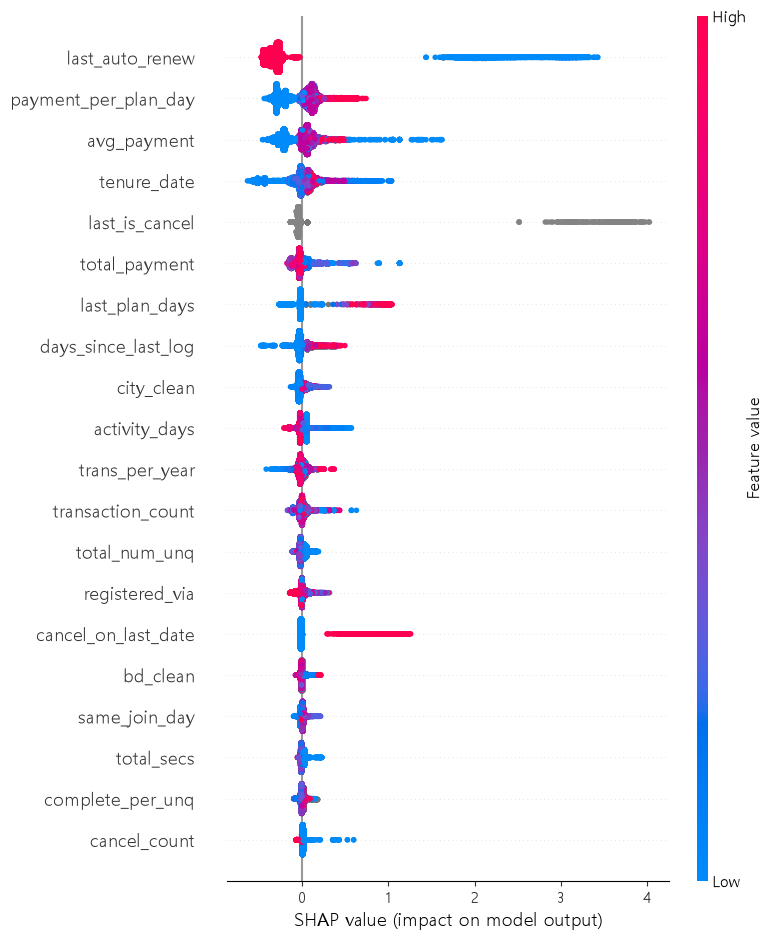

In [43]:

X_te = x_test[all_col]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_te)

# 그래프용: 범주형을 숫자 코드로
X_plot = X_te.copy()
for c in categories:
    X_plot[c] = X_plot[c].cat.codes

shap.summary_plot(shap_values, X_plot)

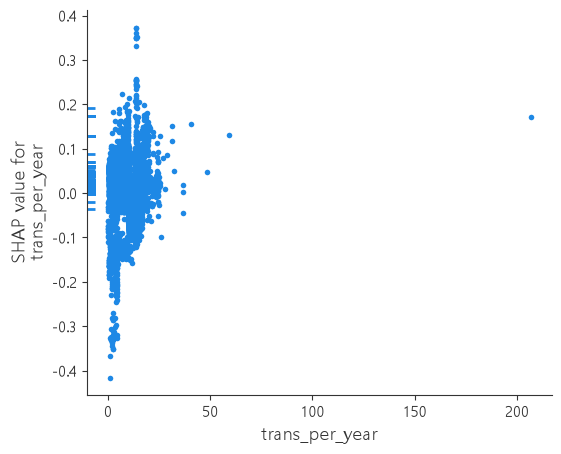

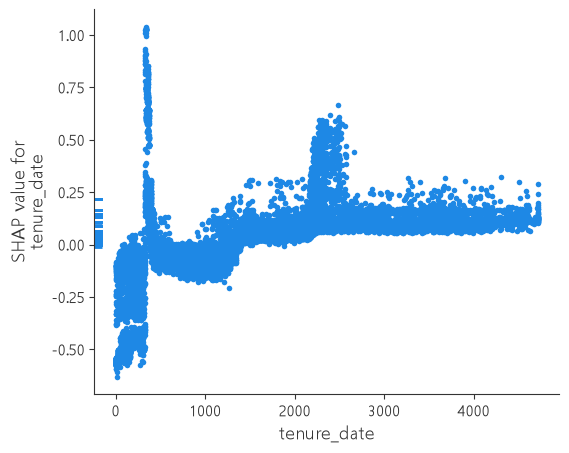

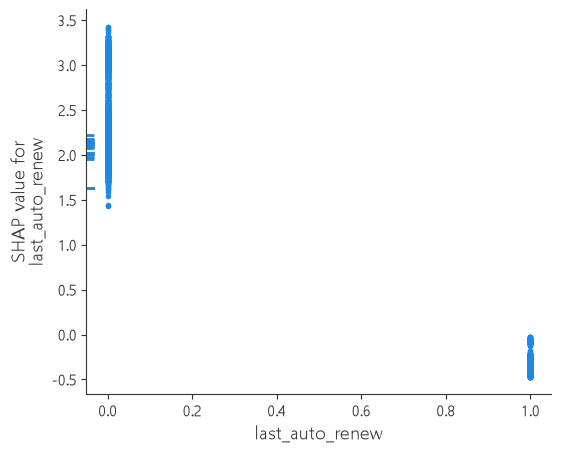

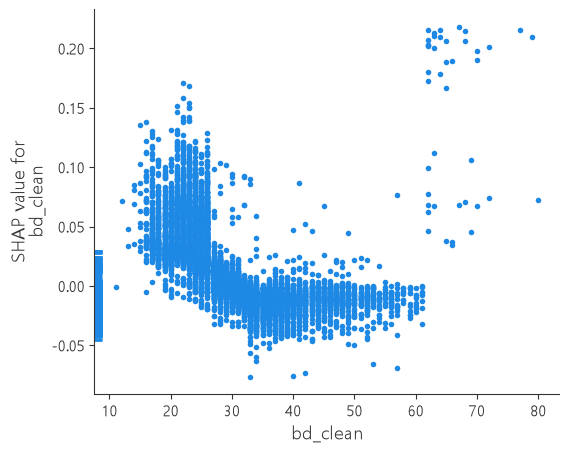

In [42]:
for col in ["trans_per_year", "tenure_date", "last_auto_renew", "bd_clean"]:
    shap.dependence_plot(col, shap_values, X_plot, interaction_index=None)